# BaseLine para Evaluación y Optimización del Modelo IA - Julio Encalada y Sara Cruz

## Proyecto

**Robot Educativo basado en Visión Artificial para apoyar la Comprensión Lectora en Educación General Básica**

**Estudiantes:** Julio Encalada y Sara Cruz  

**Modelo de visión artificial:** YOLOv8

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.3 MB/s eta 0:00:00


In [ ]:
import torch
import ultralytics
from ultralytics import YOLO

print("Versión de Ultralytics:", ultralytics.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU utilizada:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU. Cambia el entorno de ejecución a GPU.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Versión de Ultralytics: 8.4.91
GPU disponible: True
GPU utilizada: Tesla T4


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Ld5MA3ZSF8L57FTpRsFu")
project = rf.workspace("julios-workspace-3vccd").project("primerodebasica")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PrimeroDeBasica-1 in yolov8:: 100%|██████████| 846/846 [00:00<00:00, 8026.38it/s]


In [ ]:
import glob
import os

archivos_yaml = glob.glob("/content/**/*.yaml", recursive=True)

print("Archivos YAML encontrados:\n")

for archivo in archivos_yaml:
    print(archivo)

Archivos YAML encontrados:

/content/PrimeroDeBasica-1/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

results = model.train(
    data="/content/PrimeroDeBasica-1/data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    patience=15,
    project="Benchmark",
    name="Baseline_YOLOv8n"
)

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PrimeroDeBasica-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Baseline_YOLOv8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

In [ ]:
import os
import glob

ruta_resultados = "/content/runs/detect/Benchmark/Baseline_YOLOv8n"

archivos = glob.glob(ruta_resultados + "/*")

print("Archivos generados:\n")
for archivo in archivos:
    print(os.path.basename(archivo))

Archivos generados:

confusion_matrix_normalized.png
results.csv
BoxF1_curve.png
weights
val_batch0_labels.jpg
train_batch2.jpg
train_batch1.jpg
BoxPR_curve.png
val_batch1_pred.jpg
train_batch0.jpg
labels.jpg
results.png
confusion_matrix.png
val_batch1_labels.jpg
args.yaml
BoxP_curve.png
val_batch0_pred.jpg
BoxR_curve.png


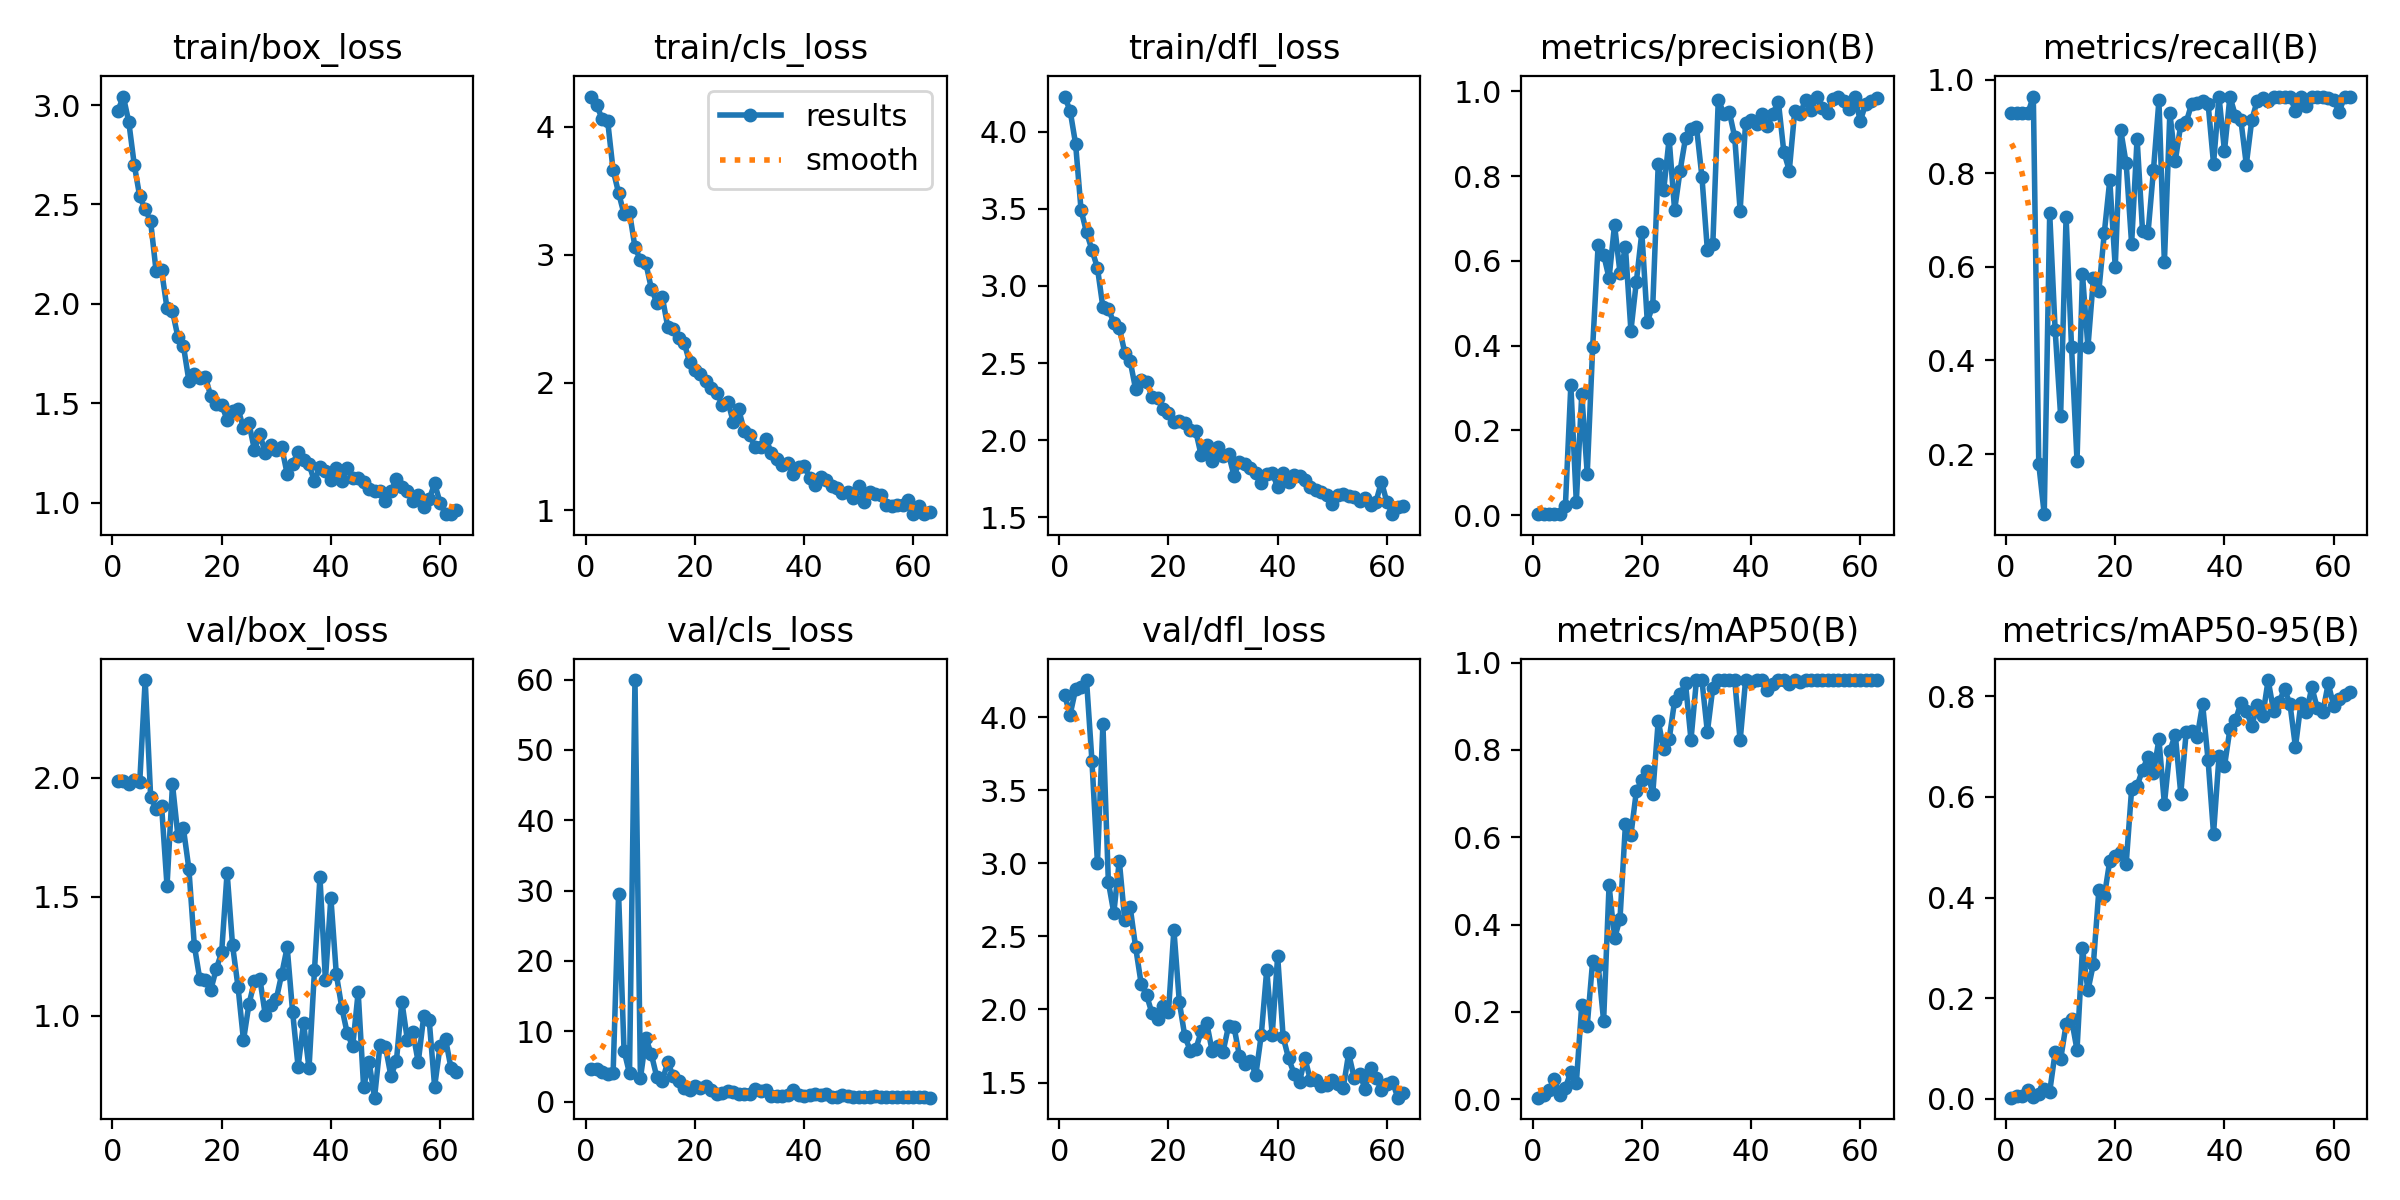

In [ ]:
from IPython.display import Image, display

display(Image(
    filename="/content/runs/detect/Benchmark/Baseline_YOLOv8n/results.png",
    width=900
))

confusion_matrix.png


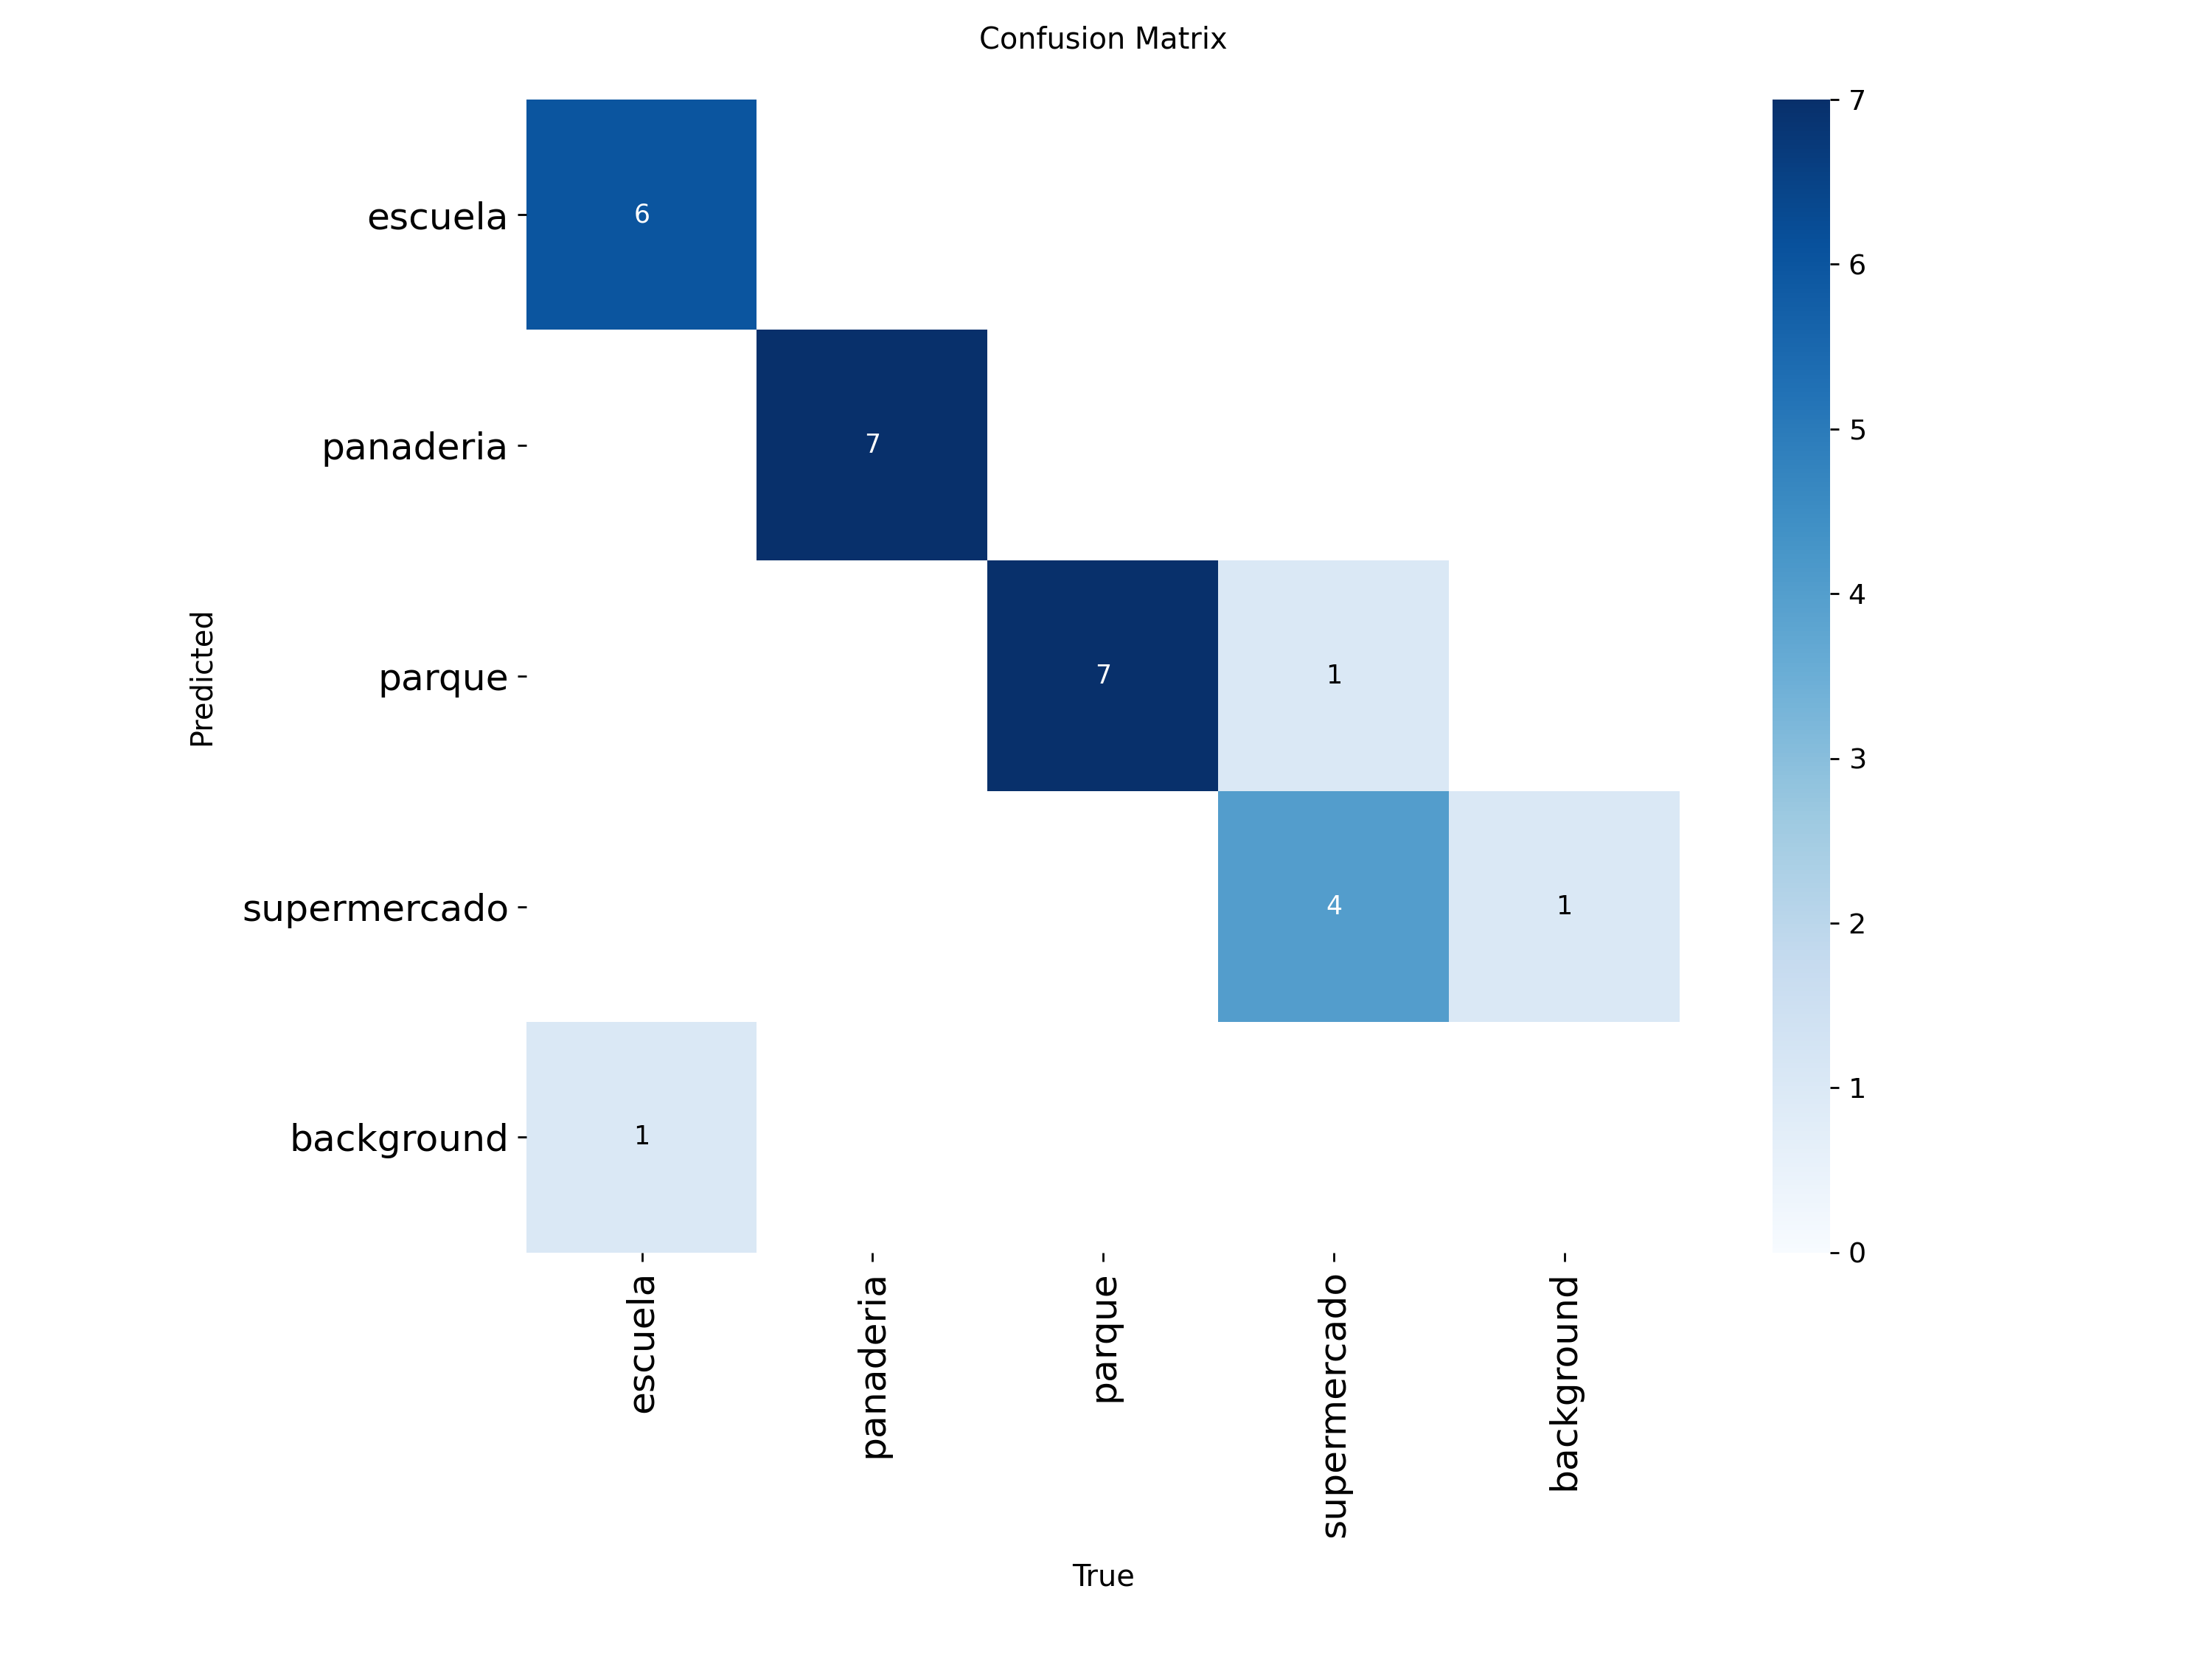

confusion_matrix_normalized.png


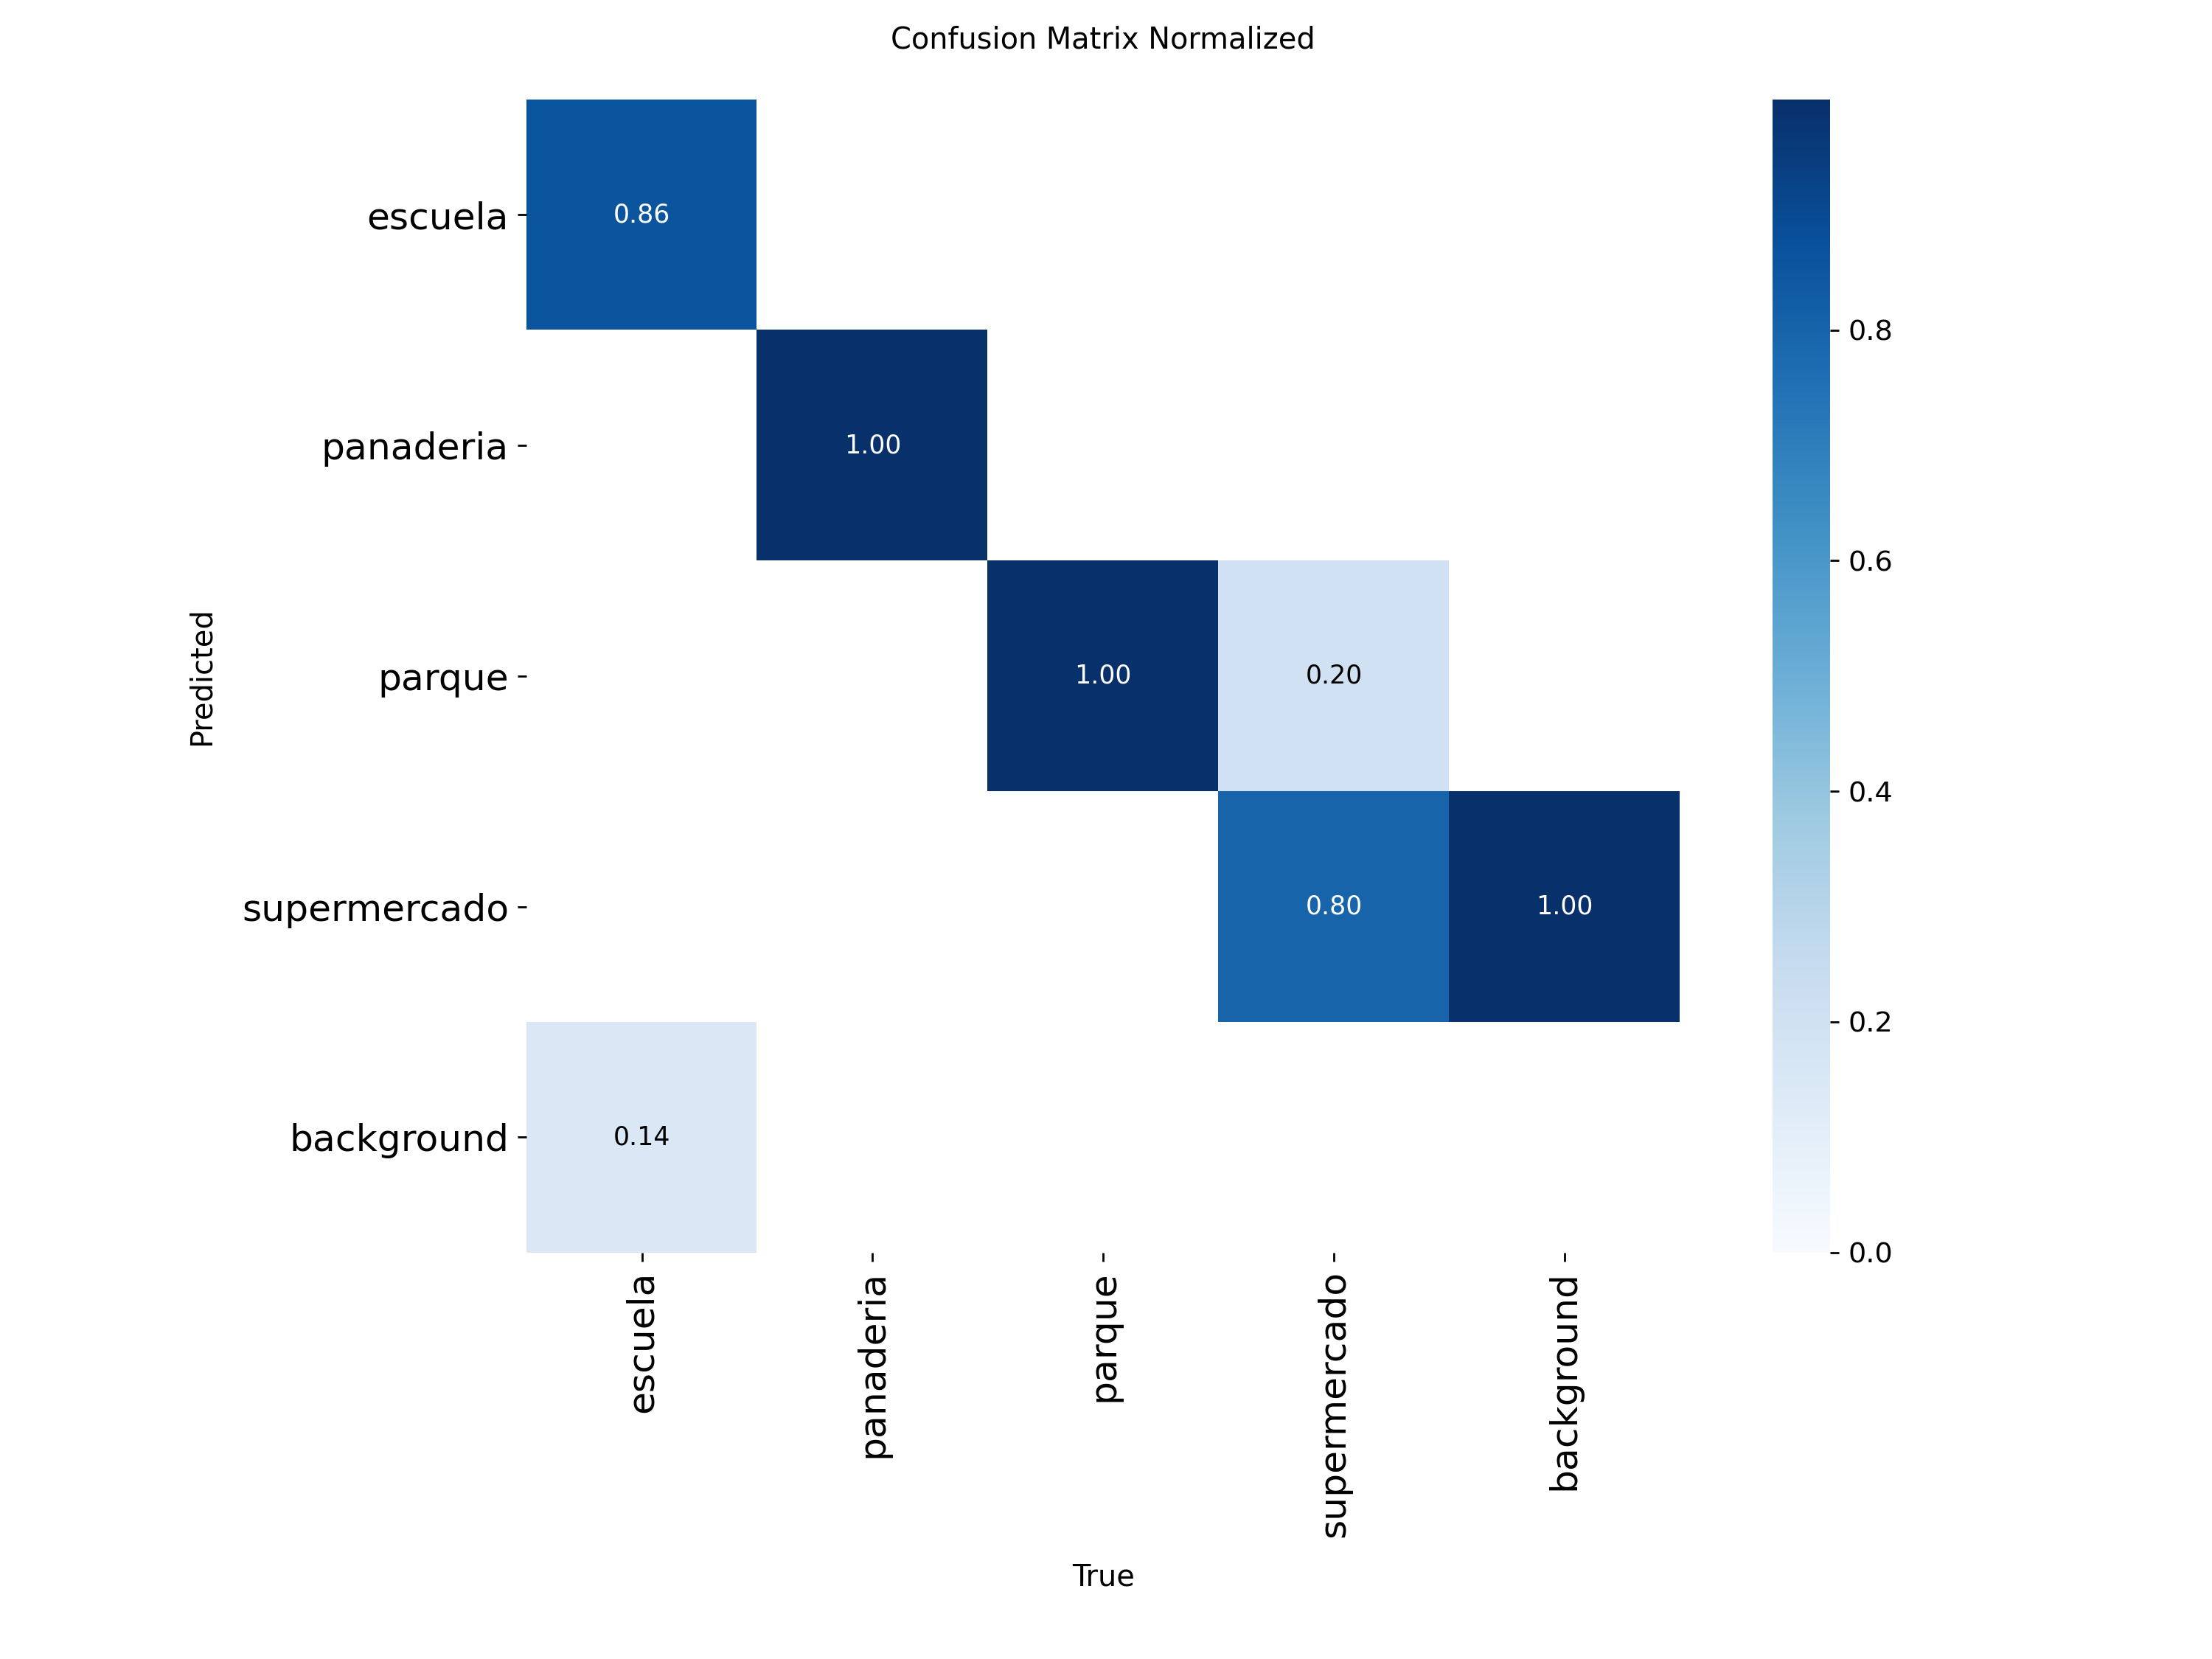

F1_curve.png


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/Benchmark/Baseline_YOLOv8n/F1_curve.png'

In [ ]:
from IPython.display import Image, display

imagenes = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png"
]

ruta = "/content/runs/detect/Benchmark/Baseline_YOLOv8n/"

for img in imagenes:
    print("="*70)
    print(img)
    display(Image(filename=ruta + img, width=650))

In [ ]:
import os

ruta = "/content/runs/detect/Benchmark/Baseline_YOLOv8n"

print("Archivos encontrados:\n")

for archivo in sorted(os.listdir(ruta)):
    print(archivo)

Archivos encontrados:

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
weights



 BoxF1_curve.png


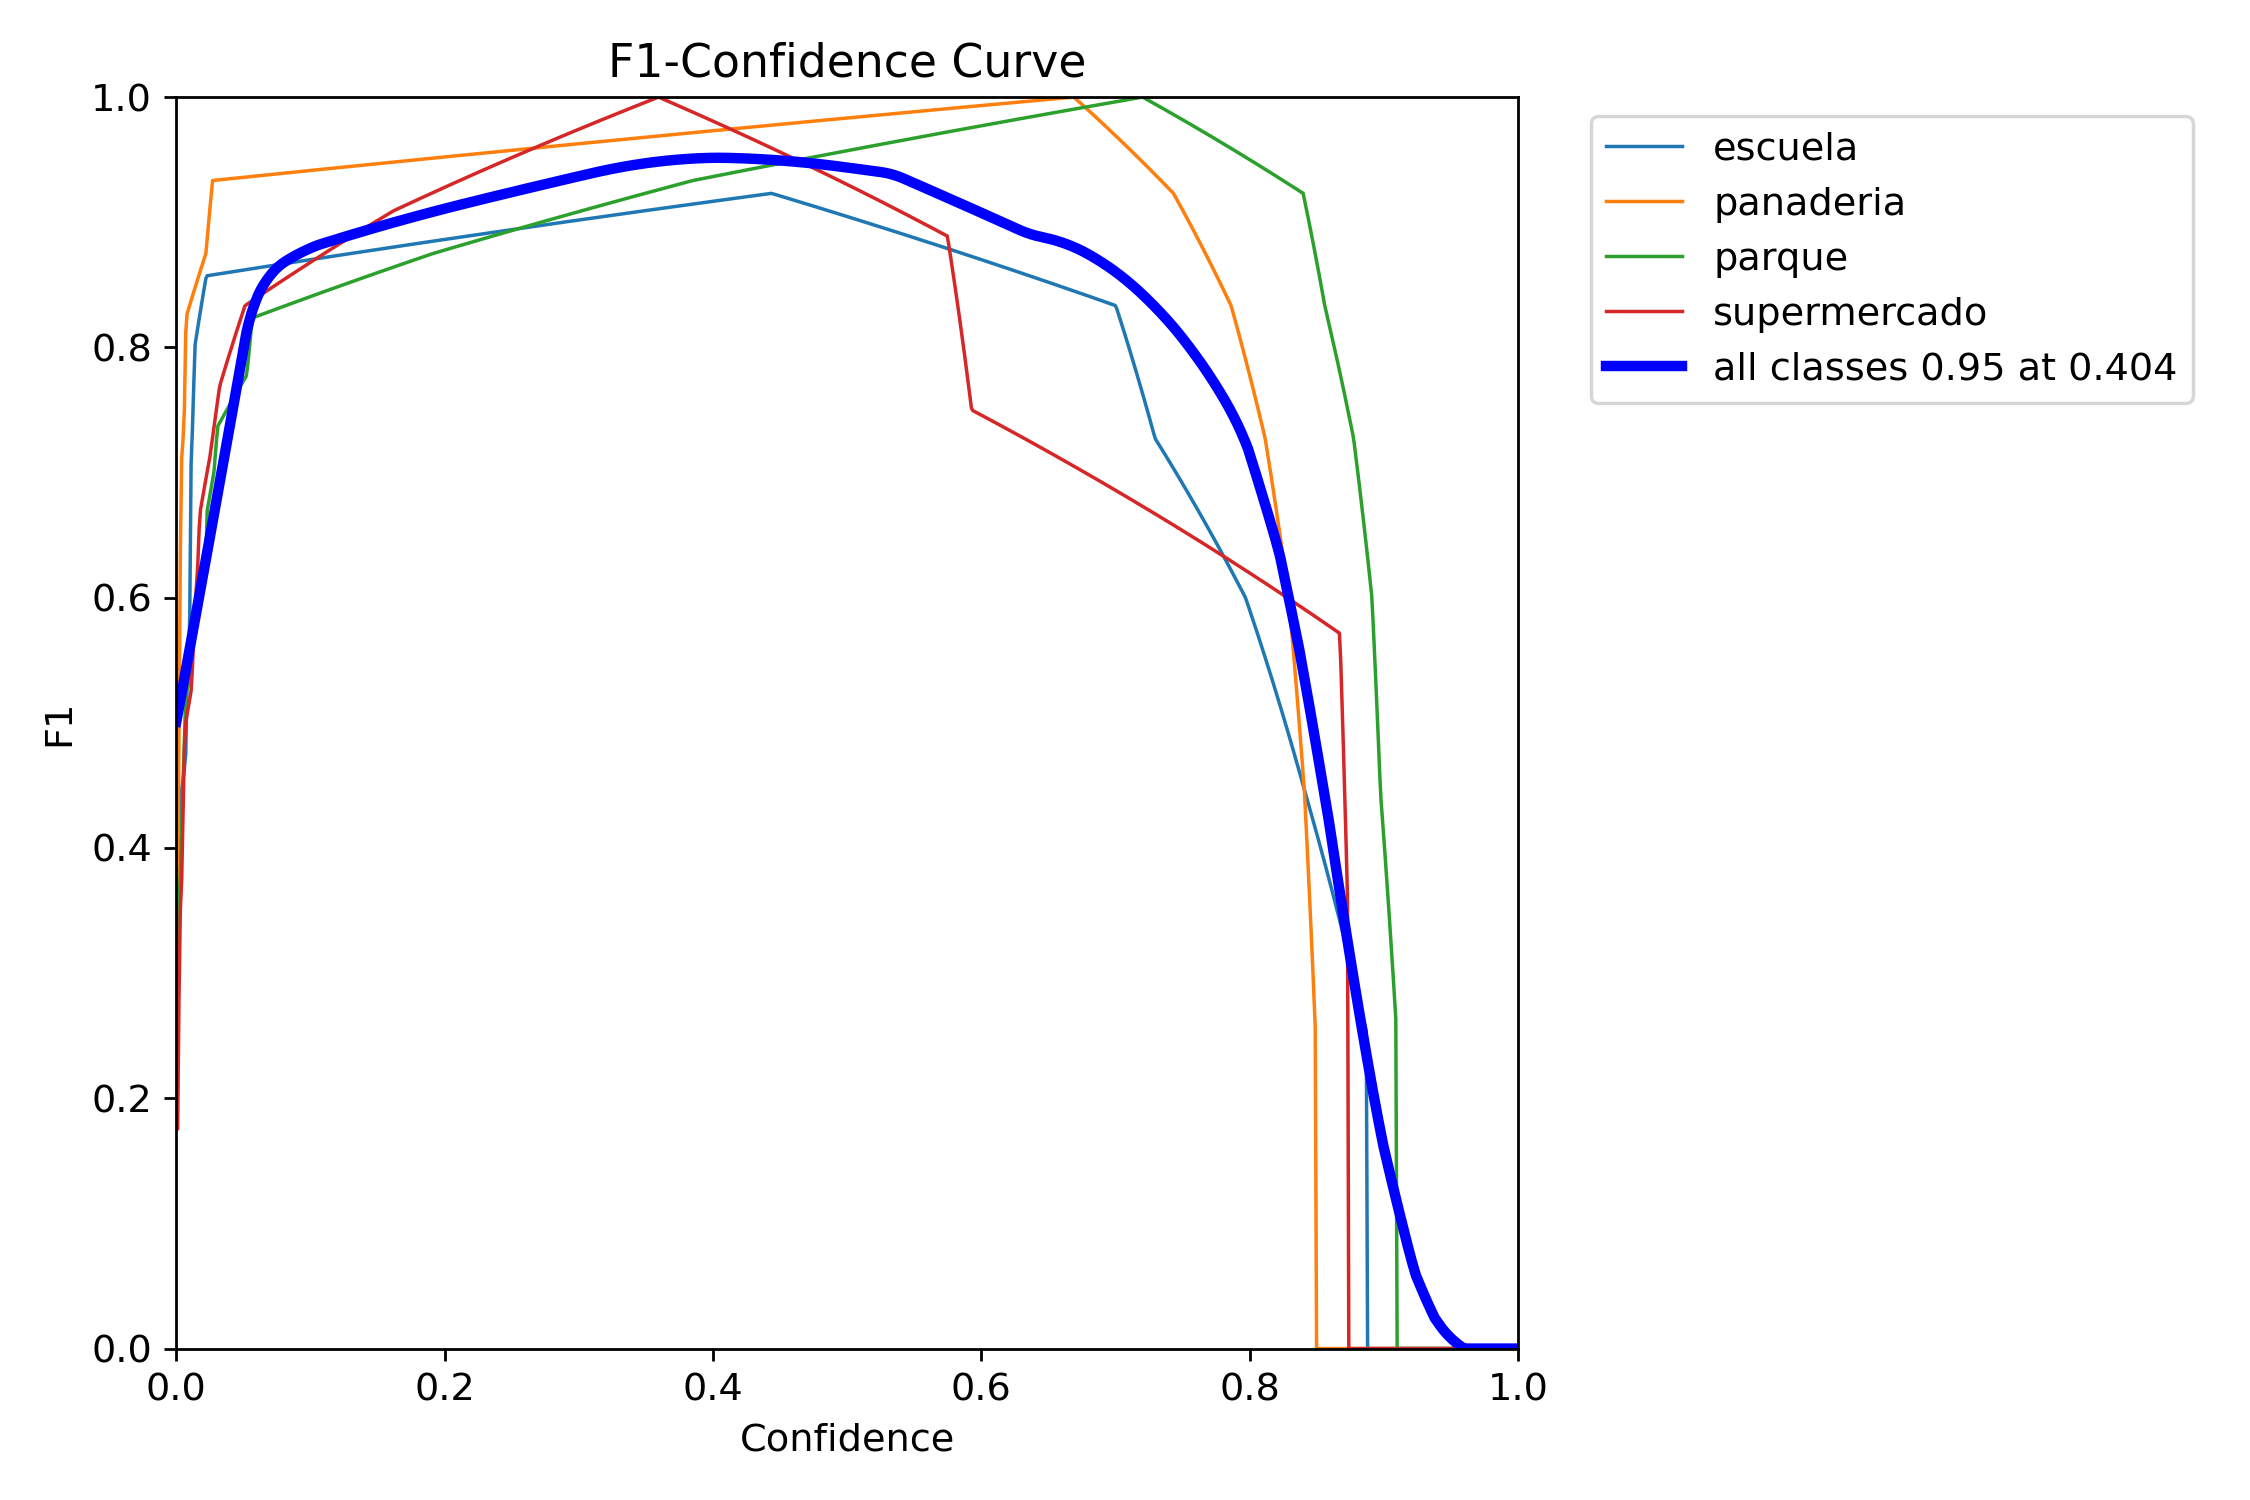


 BoxP_curve.png


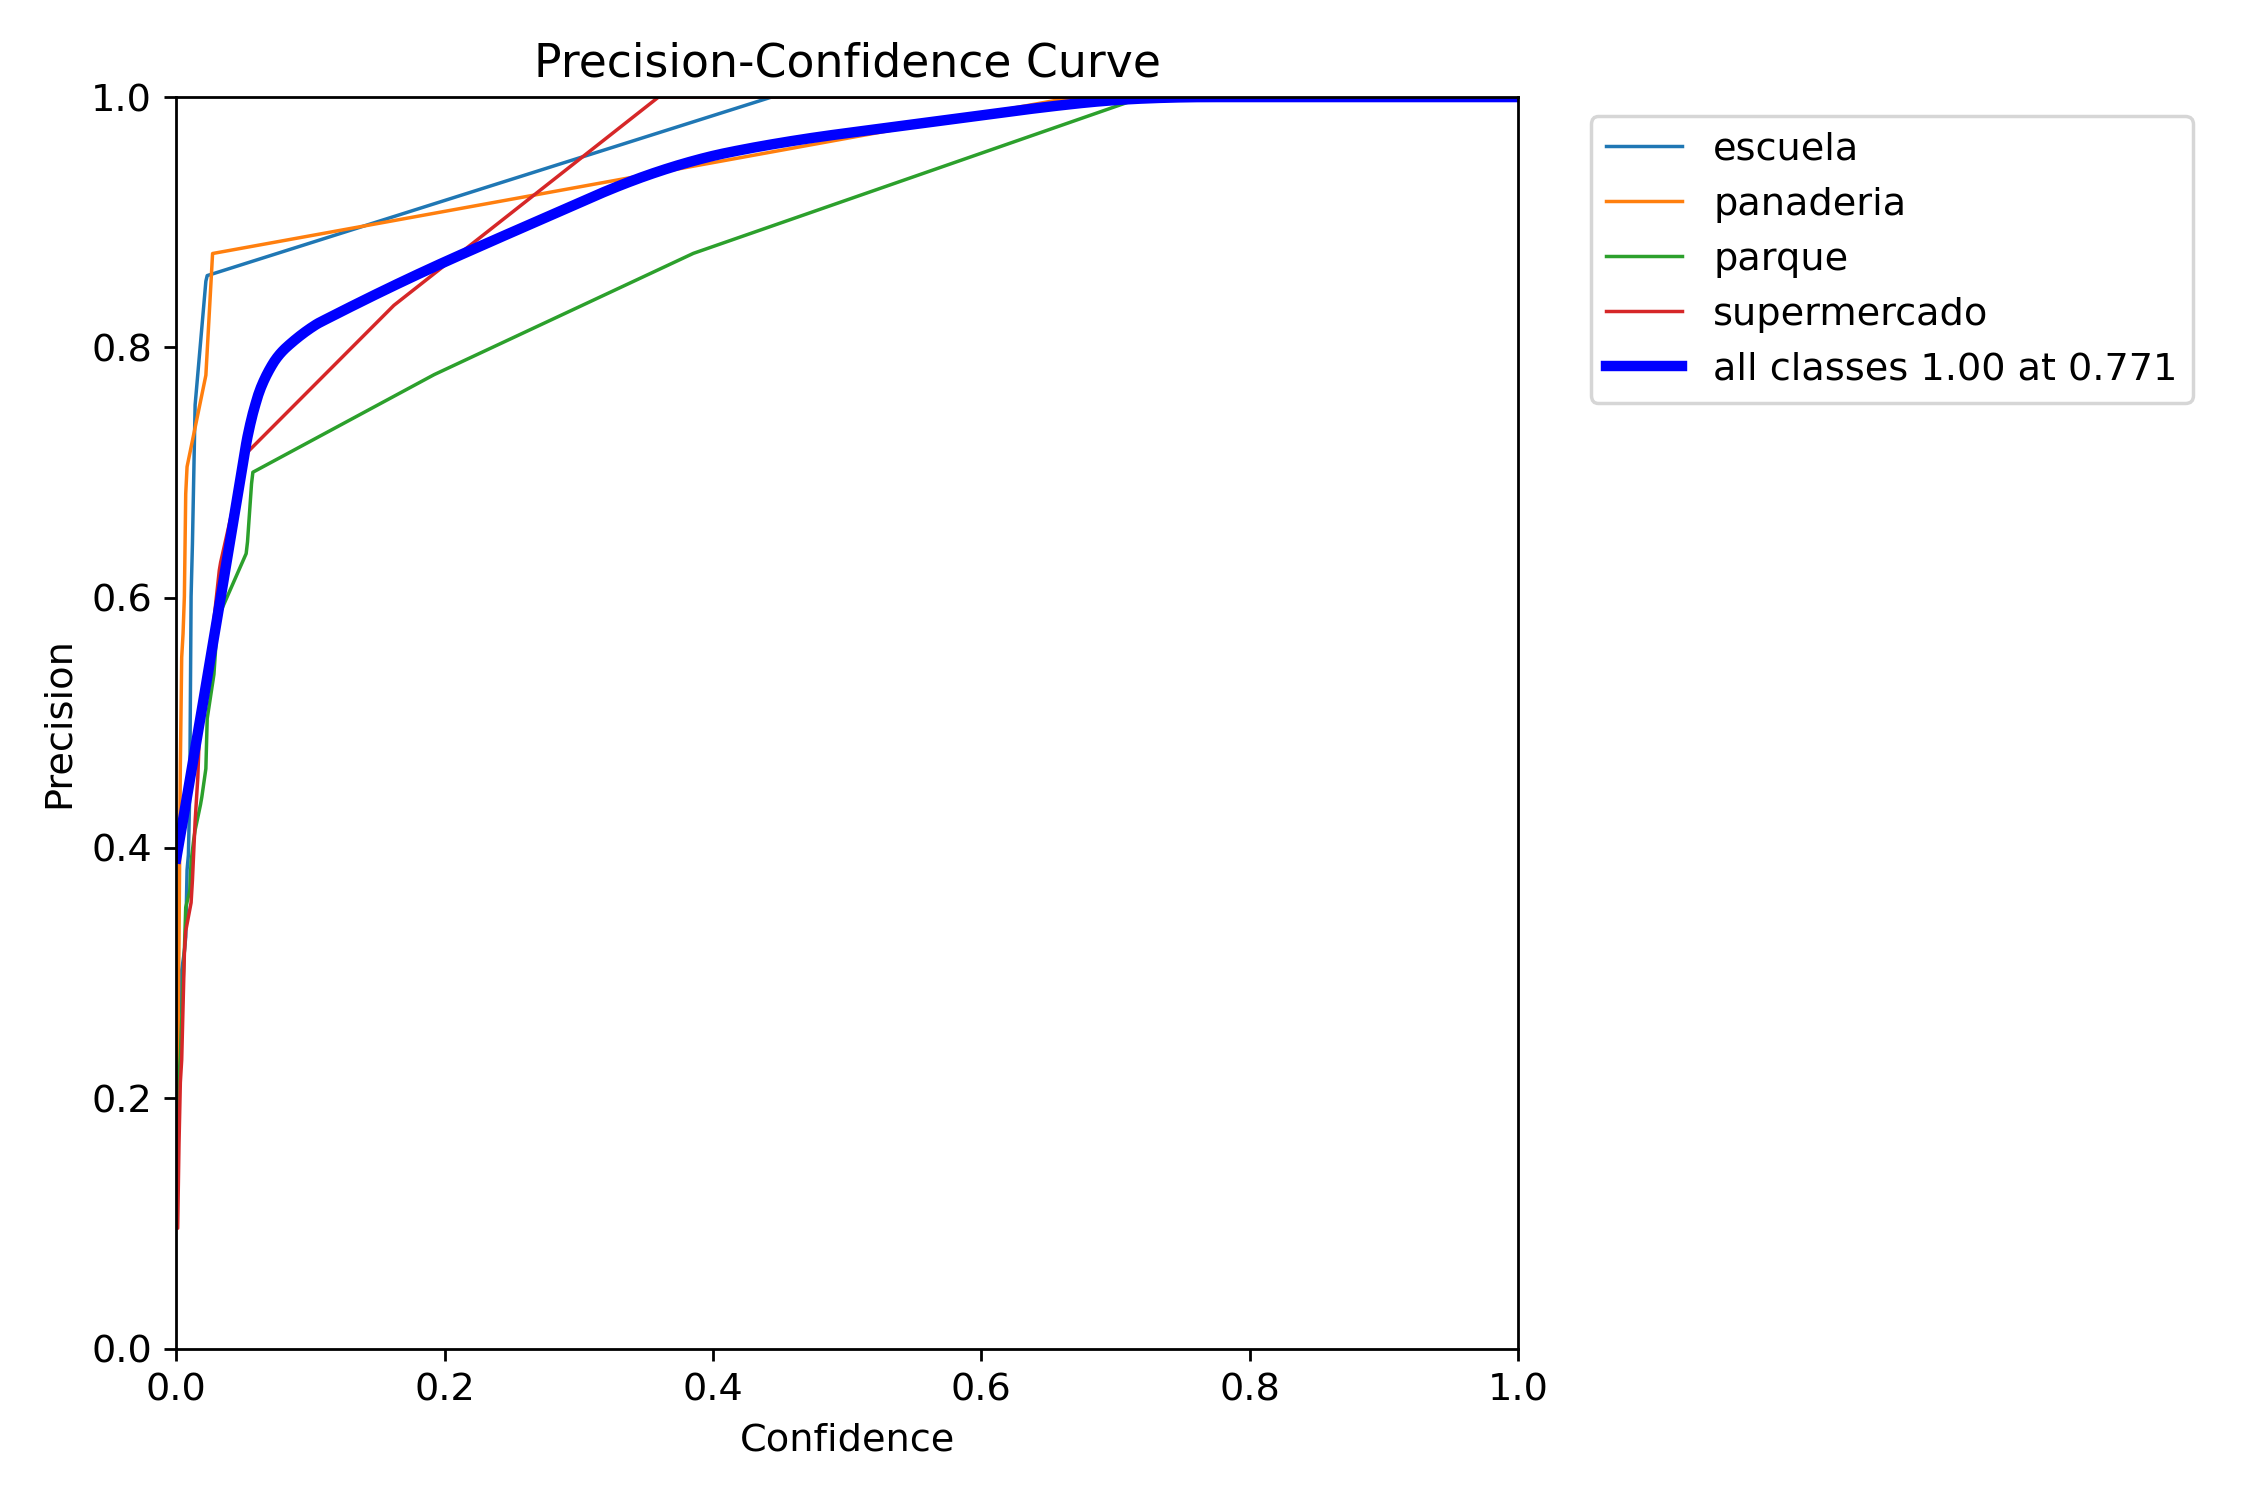


 BoxR_curve.png


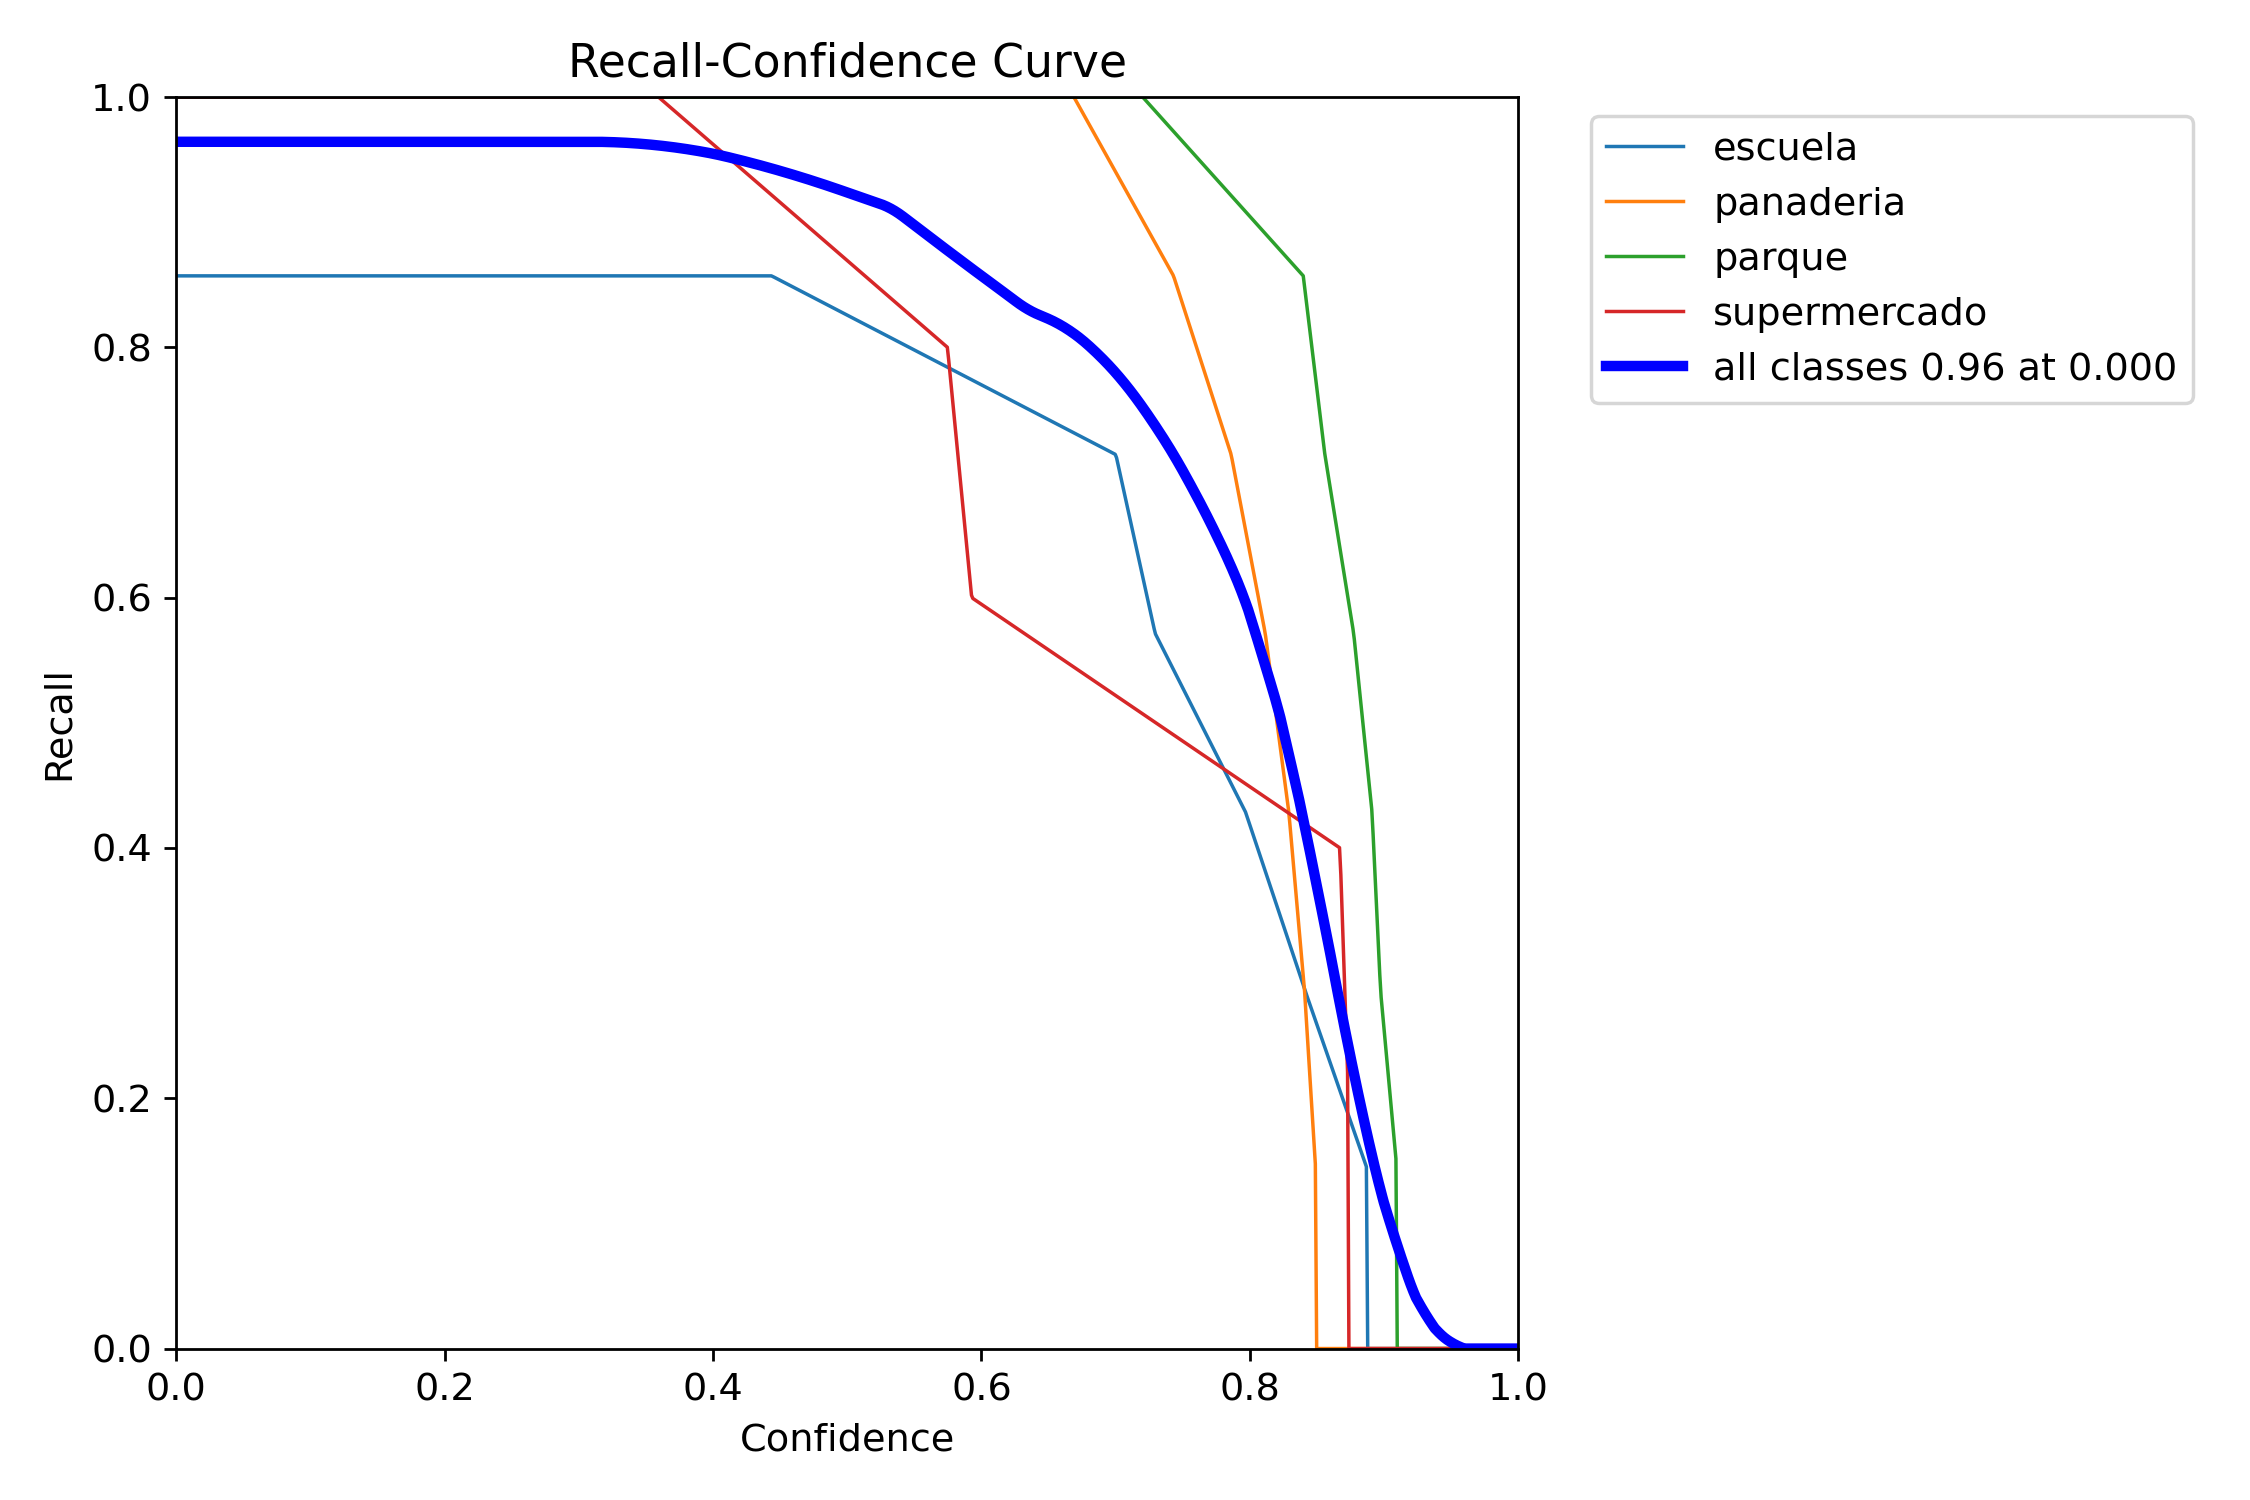


 BoxPR_curve.png


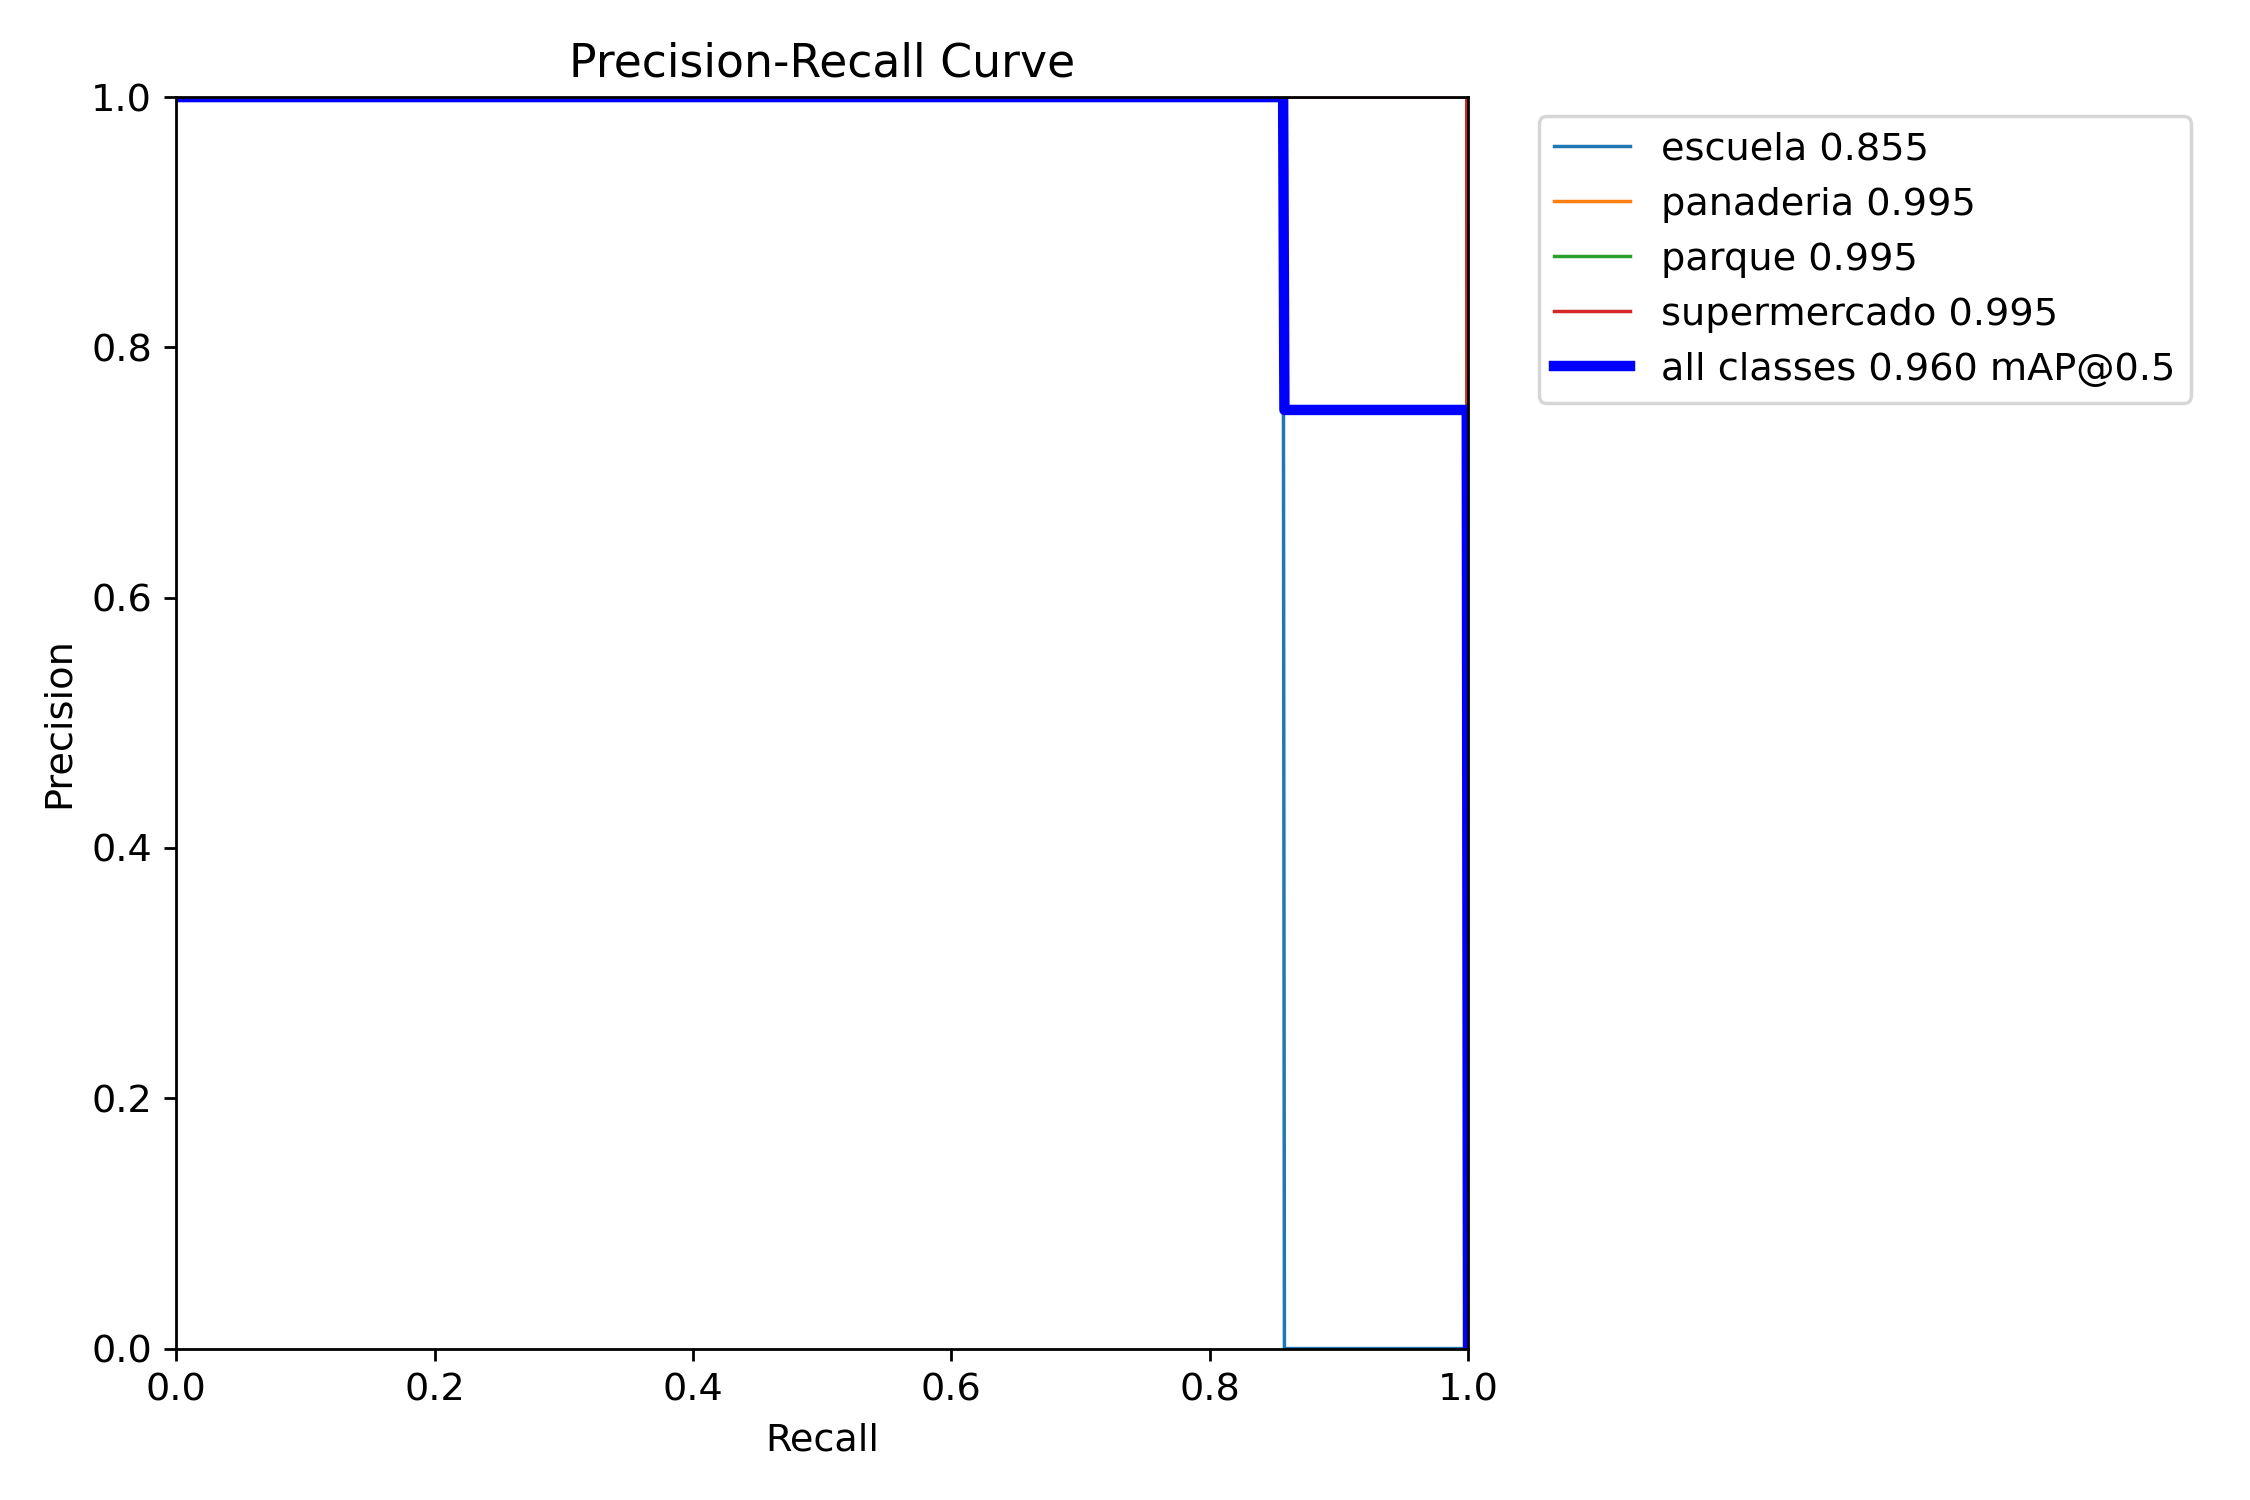

In [ ]:
from IPython.display import Image, display

ruta="/content/runs/detect/Benchmark/Baseline_YOLOv8n/"

imagenes=[
"BoxF1_curve.png",
"BoxP_curve.png",
"BoxR_curve.png",
"BoxPR_curve.png"
]

for img in imagenes:
    print("\n",img)
    display(Image(filename=ruta+img,width=700))

In [ ]:
ruta_yaml = "/content/PrimeroDeBasica-1/data.yaml"

with open(ruta_yaml, "r", encoding="utf-8") as archivo:
    print(archivo.read())